In [1]:
import pandas as pd

df = pd.read_csv("Heart_Disease.csv")
df.head()
df.info()

/tmp/ipykernel_782/1628958433.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Heart_Disease.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5770240 entries, 0 to 5770239
Data columns (total 21 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Year                        object 
 1   LocationAbbr                object 
 2   LocationDesc                object 
 3   GeographicLevel             object 
 4   DataSource                  object 
 5   Class                       object 
 6   Topic                       object 
 7   Data_Value                  float64
 8   Data_Value_Unit             object 
 9   Data_Value_Type             object 
 10  Data_Value_Footnote_Symbol  object 
 11  Data_Value_Footnote         object 
 12  Confidence_limit_Low        float64
 13  Confidence_limit_High       float64
 14  StratificationCategory1     object 
 15  Stratification1             object 
 16  StratificationCategory2     object 
 17  Stratification2             object 
 18  StratificationCategory3     object 
 19  Stratification3      

In [3]:
# Step 2: Fix Core Columns
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Data_Value'] = pd.to_numeric(df['Data_Value'], errors='coerce')

df = df.dropna(subset=['Year', 'Data_Value'])
df['Year'] = df['Year'].astype(int)

In [4]:
# Step 3: Create Time Series (Baseline)
ts = df.groupby('Year')['Data_Value'].mean()
ts = ts.sort_index()

print(ts)

Year
1999    654.378824
2000    637.858300
2001    617.989555
2002    608.264816
2003    589.616238
2004    550.562482
2005    539.879701
2006    508.711408
2007    487.687681
2008    478.739133
2009    454.980428
2010    447.857377
2011    434.128569
2012    425.389171
2013    424.029768
2014    418.242061
2015    422.396760
2016    414.954829
2017    415.286313
2018    410.242330
2019    406.414249
Name: Data_Value, dtype: float64


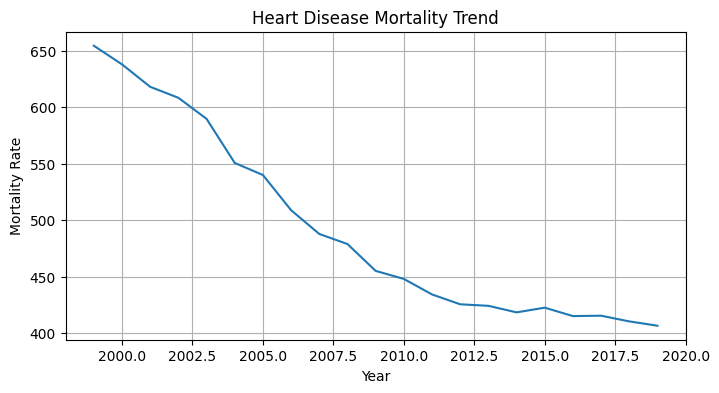

In [5]:
# Step 4: Plot the Time Series
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(ts)
plt.title("Heart Disease Mortality Trend")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.grid()
plt.show()

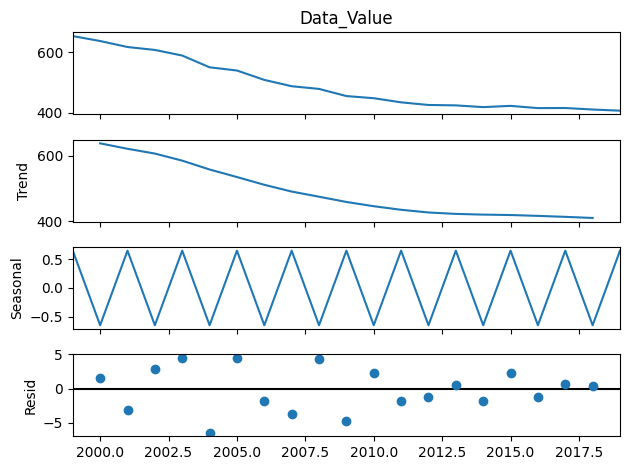

In [8]:
# Step 5: Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ts, model='additive', period=2)
fig = result.plot()
plt.show()

In [9]:
window = 3
ts_ma = ts.rolling(window=window, center=True).mean()
ts_detrended = ts - ts_ma

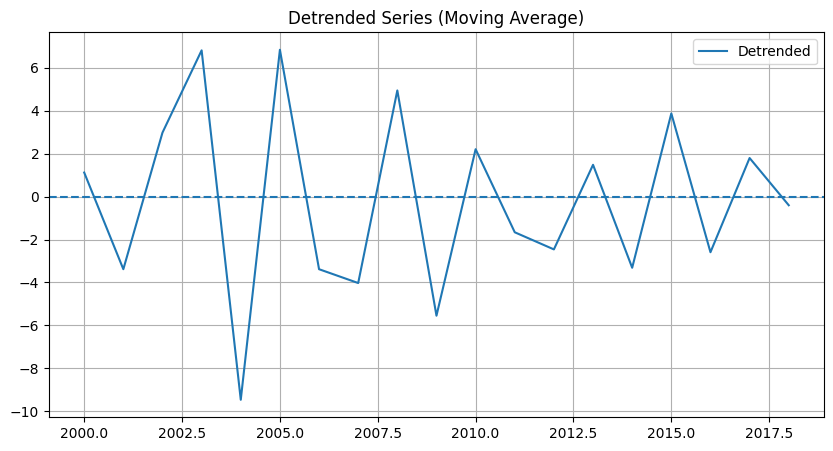

In [10]:
plt.figure(figsize=(10,5))
plt.plot(ts_detrended, label='Detrended')
plt.axhline(0, linestyle='--')
plt.legend()
plt.title("Detrended Series (Moving Average)")
plt.grid()
plt.show()

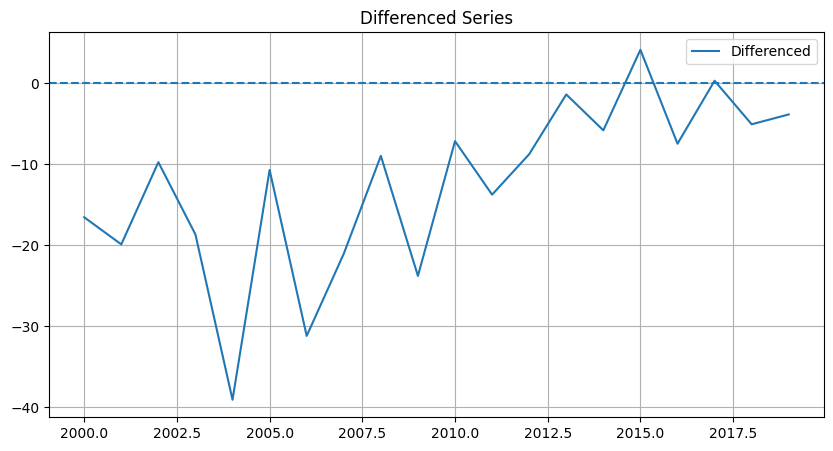

In [11]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(ts_diff, label='Differenced')
plt.axhline(0, linestyle='--')
plt.legend()
plt.title("Differenced Series")
plt.grid()
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n{name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(ts, "Original")
adf_test(ts_detrended, "MA Detrended")
adf_test(ts_diff, "Differenced")


Original
ADF Statistic: -3.234084940691736
p-value: 0.01809456284684964

MA Detrended
ADF Statistic: -2.198592519844088
p-value: 0.20675668751100146

Differenced
ADF Statistic: -9.797427479468166
p-value: 6.121275525972514e-17


Moving average is useful for visualization and trend estimation

Differencing is more effective for achieving stationarity

Therefore, differenced data is preferred for modeling

In [24]:
ts = df.groupby('Year')['Data_Value'].mean().sort_index()
ts.index = pd.to_datetime(ts.index, format='%Y')

In [25]:
ts = ts.asfreq('YS')   # Year Start frequency

In [26]:
train = ts[:int(len(ts)*0.8)]
test = ts[int(len(ts)*0.8):]

In [27]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))  # since differencing works
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # VERY IMPORTANT

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


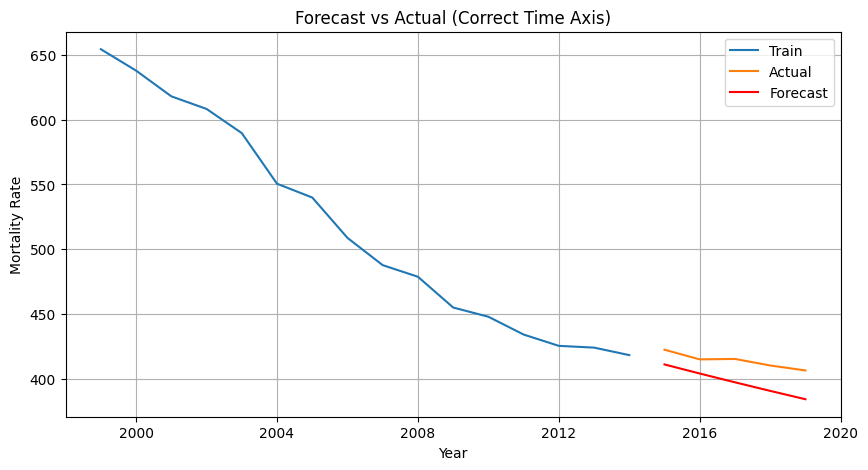

In [28]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(forecast.index, forecast, label='Forecast', color='red')

plt.legend()
plt.title("Forecast vs Actual (Correct Time Axis)")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.grid()
plt.show()

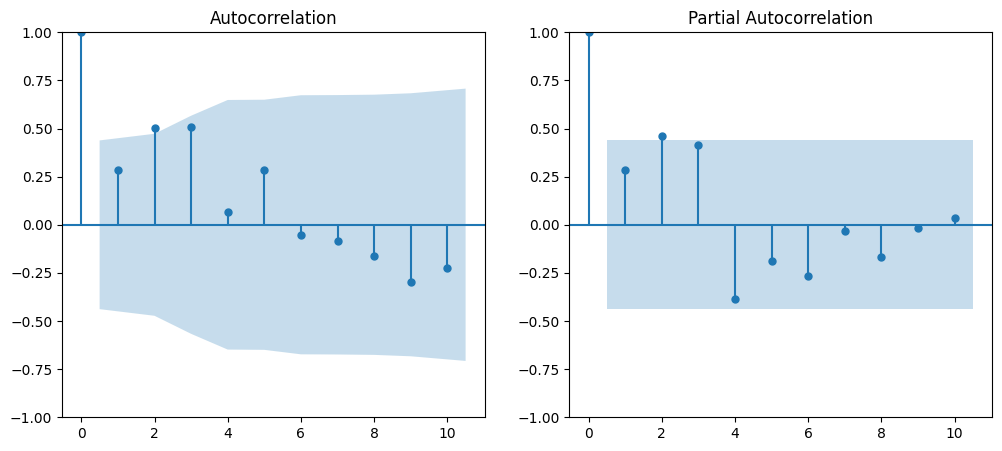

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(ts_diff, ax=plt.gca(), lags=10)

plt.subplot(1,2,2)
plot_pacf(ts_diff, ax=plt.gca(), lags=10)

plt.show()

In [30]:
model1 = ARIMA(train, order=(1,1,1)).fit()
model2 = ARIMA(train, order=(2,1,1)).fit()
model3 = ARIMA(train, order=(1,1,2)).fit()

print(model1.aic, model2.aic, model3.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


119.72873899479369 122.9092829100746 117.86907892316509


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


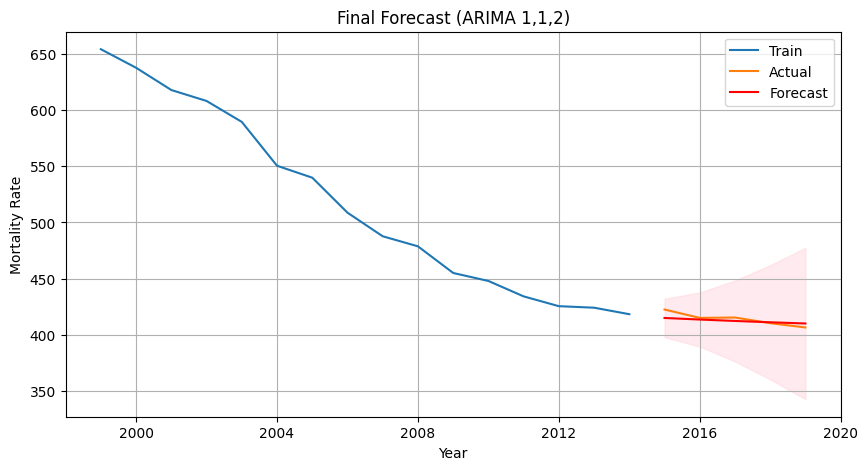

In [31]:
model_best = ARIMA(train, order=(1,1,2))
model_best_fit = model_best.fit(method_kwargs={"maxiter": 200})

forecast_res = model_best_fit.get_forecast(steps=len(test))

forecast = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

forecast.index = test.index
conf_int.index = test.index

plt.figure(figsize=(10,5))

plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast', color='red')

plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("Final Forecast (ARIMA 1,1,2)")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.grid()
plt.show()

In [32]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test, forecast)
print("MSE (ARIMA 1,1,2):", mse)

MSE (ARIMA 1,1,2): 16.29335760035756


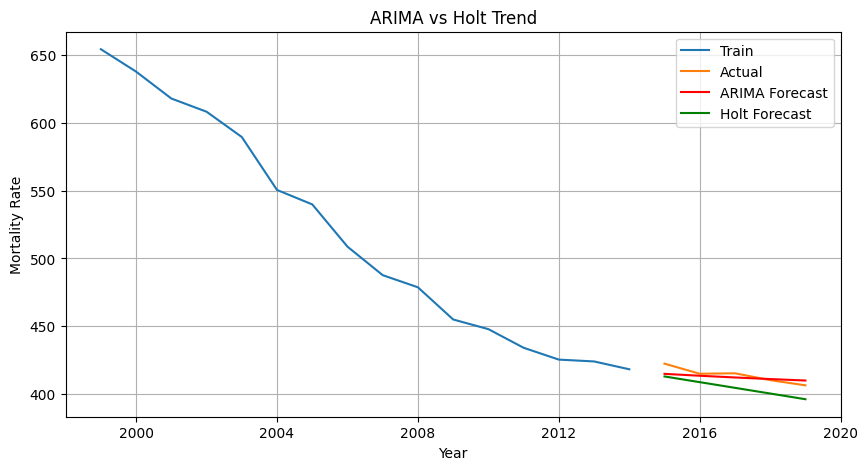

In [35]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit model
holt_model = ExponentialSmoothing(train, trend='add', seasonal=None)
holt_fit = holt_model.fit()

# Forecast
holt_forecast = holt_fit.forecast(len(test))

# Align index
holt_forecast.index = test.index

plt.figure(figsize=(10,5))

plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='ARIMA Forecast', color='red')
plt.plot(holt_forecast, label='Holt Forecast', color='green')

plt.legend()
plt.title("ARIMA vs Holt Trend")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.grid()
plt.show()

In [36]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse_holt = mean_squared_error(test, holt_forecast)
rmse_holt = np.sqrt(mse_holt)

print("Holt MSE:", mse_holt)
print("Holt RMSE:", rmse_holt)

Holt MSE: 89.10851091688096
Holt RMSE: 9.439730447257537


In [37]:
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=2)
hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(len(test))
hw_forecast.index = test.index

🧾 5. What to WRITE in report (VERY IMPORTANT)
About Holt:

“Holt’s linear trend model was applied to capture the decreasing trend in mortality data.”

About Holt-Winters:

“Holt-Winters was not emphasized as the dataset does not exhibit clear seasonal patterns.”